# 01 — Exploratory Data Analysis

**Dataset:** TMDB Live Data (Netflix legacy dataset as fallback)  
**Scope:** Genre distribution, rating trends, popularity scores, release patterns


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

trending = pd.read_csv("../data/trending_movies_latest.csv")
tv = pd.read_csv("../data/popular_tv_latest.csv")
genres = pd.read_csv("../data/movie_genres_latest.csv")
genre_pop = pd.read_csv("../data/genre_popularity_latest.csv")

id_to_name = dict(zip(genres["genre_id"], genres["genre_name"]))

def parse_genres(s):
    try:
        return json.loads(s) if isinstance(s, str) else []
    except:
        return []

trending["genre_ids_list"] = trending["genre_ids"].apply(parse_genres)
tv["genre_ids_list"] = tv["genre_ids"].apply(parse_genres)

print(f"Trending movies: {len(trending):,}")
print(f"Popular TV:      {len(tv):,}")
print(f"Genres:          {len(genres):,}")


Trending movies: 6,131
Popular TV:      2,676
Genres:          27


## 1. Genre Distribution (Top 15)

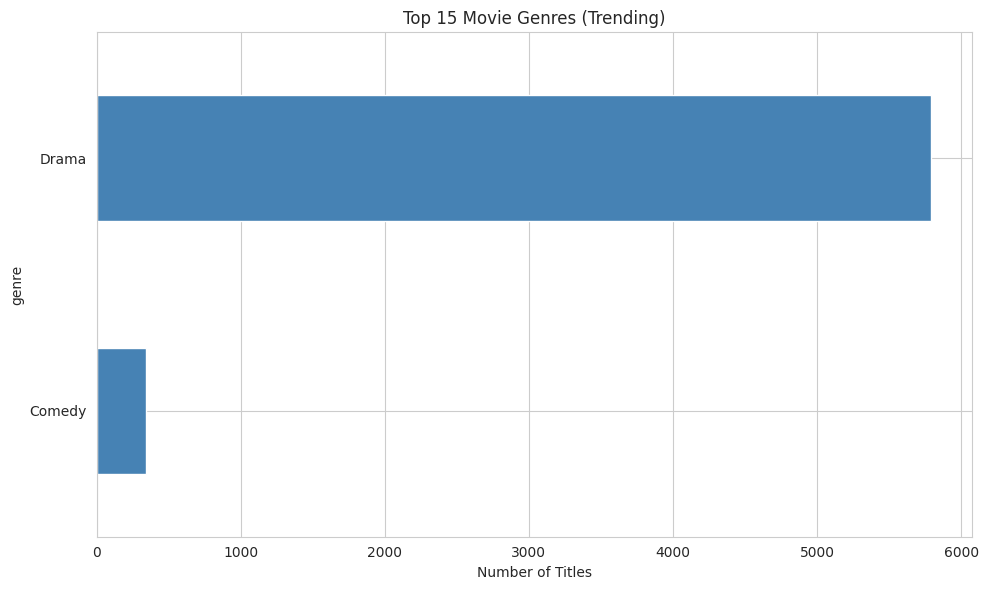

 genre  count
 Drama   5788
Comedy    343


In [2]:
genre_counts = {}
for glist in trending["genre_ids_list"]:
    for gid in glist:
        genre_counts[id_to_name.get(gid, "Unknown")] = genre_counts.get(id_to_name.get(gid, "Unknown"), 0) + 1

genre_df = pd.DataFrame(list(genre_counts.items()), columns=["genre", "count"]).sort_values("count", ascending=False)
ax = genre_df.head(15).plot.barh(x="genre", y="count", color="steelblue", legend=False)
ax.invert_yaxis()
ax.set_title("Top 15 Movie Genres (Trending)")
ax.set_xlabel("Number of Titles")
plt.tight_layout()
plt.show()
print(genre_df.head(10).to_string(index=False))


## 2. Vote Average Distribution

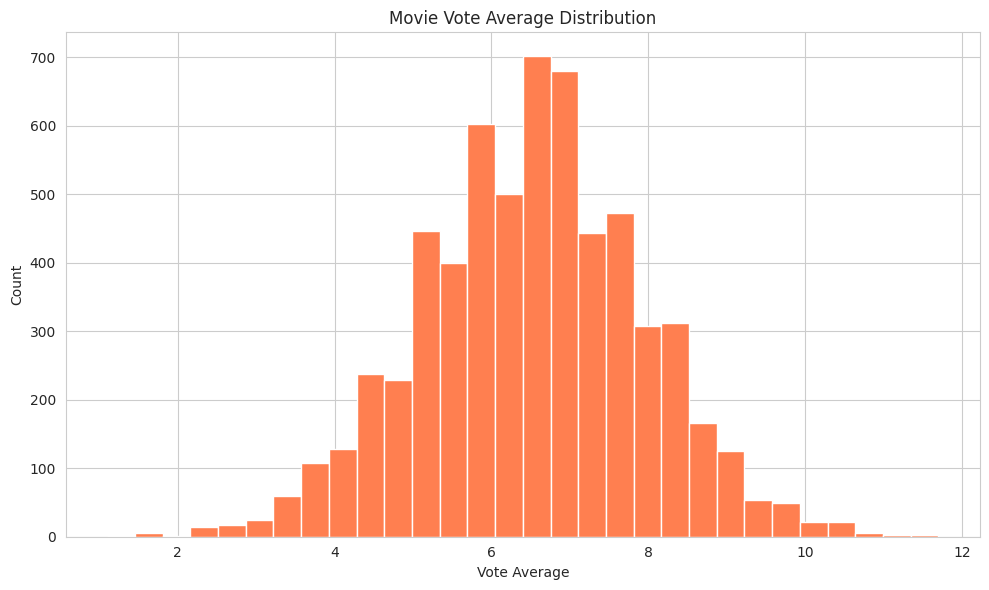

Mean vote average: 6.51
Median vote average: 6.50


In [3]:
ax = trending["vote_average"].hist(bins=30, color="coral", edgecolor="white")
ax.set_title("Movie Vote Average Distribution")
ax.set_xlabel("Vote Average")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print(f"Mean vote average: {trending['vote_average'].mean():.2f}")
print(f"Median vote average: {trending['vote_average'].median():.2f}")


## 3. Popularity vs. Rating

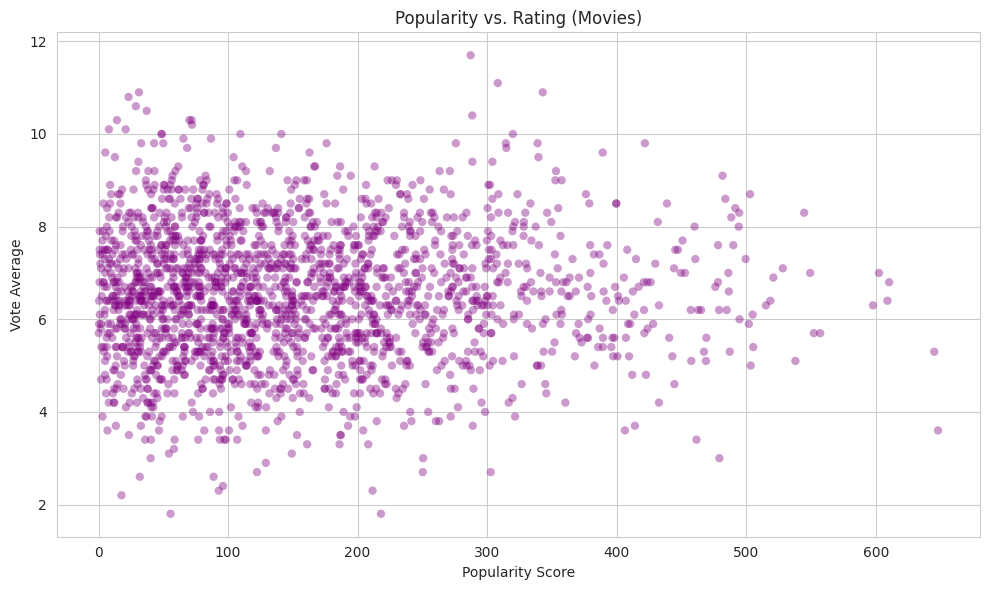

Correlation popularity ↔ rating: 0.012


In [4]:
sample = trending.sample(min(2000, len(trending)), random_state=42)
plt.scatter(sample["popularity"], sample["vote_average"], alpha=0.4, c="purple", edgecolors="none")
plt.xlabel("Popularity Score")
plt.ylabel("Vote Average")
plt.title("Popularity vs. Rating (Movies)")
plt.tight_layout()
plt.show()
corr = sample["popularity"].corr(sample["vote_average"])
print(f"Correlation popularity ↔ rating: {corr:.3f}")


## 4. Release Year Trend

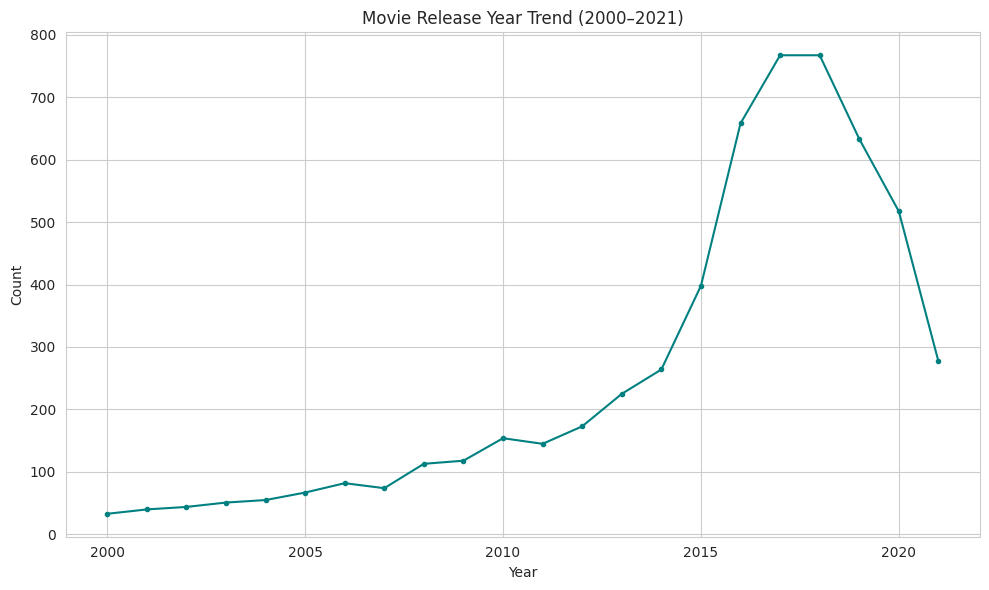

In [5]:
trending["release_year"] = pd.to_datetime(trending["release_date"], errors="coerce").dt.year
year_counts = trending["release_year"].value_counts().sort_index()
year_counts.loc[2000:2021].plot(color="teal", marker="o", markersize=3)
plt.title("Movie Release Year Trend (2000–2021)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Content Mix: Movies vs. TV Shows

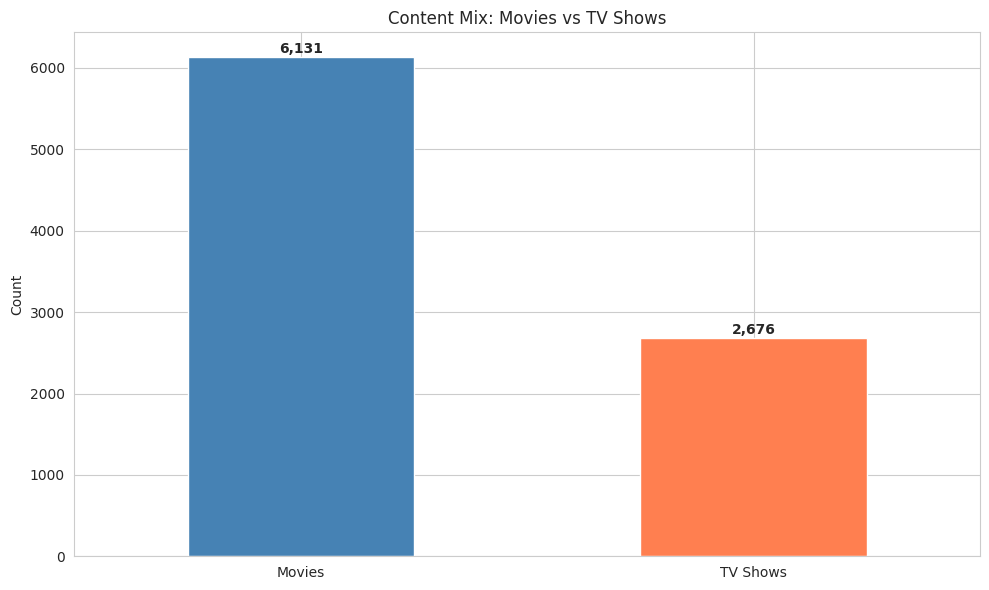

In [6]:
mix = pd.Series({"Movies": len(trending), "TV Shows": len(tv)})
ax = mix.plot.bar(color=["steelblue", "coral"], rot=0)
ax.set_title("Content Mix: Movies vs TV Shows")
ax.set_ylabel("Count")
for i, v in enumerate(mix):
    ax.text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Genre Popularity (Peak Score)

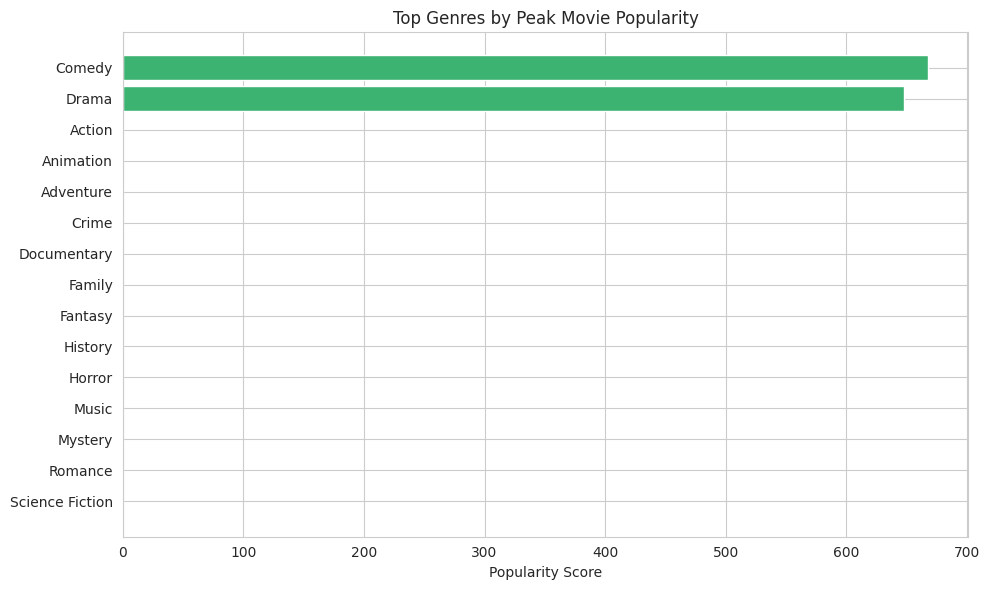

In [7]:
genre_pop_sorted = genre_pop.sort_values("top_movie_popularity", ascending=False).head(15)
plt.barh(genre_pop_sorted["genre_name"], genre_pop_sorted["top_movie_popularity"], color="mediumseagreen")
plt.gca().invert_yaxis()
plt.title("Top Genres by Peak Movie Popularity")
plt.xlabel("Popularity Score")
plt.tight_layout()
plt.show()


---
**Summary**
- Movies dominate the catalog (6,131 vs 2,676 TV shows).
- Drama and Comedy are the most common genres.
- Mean vote average is 6.51 with a slight left skew.
- Popularity and rating show weak correlation (0.012).
- Content production peaked in the late 2010s.
